## geometries and operators

#### 1. passing the cell in a local reference system

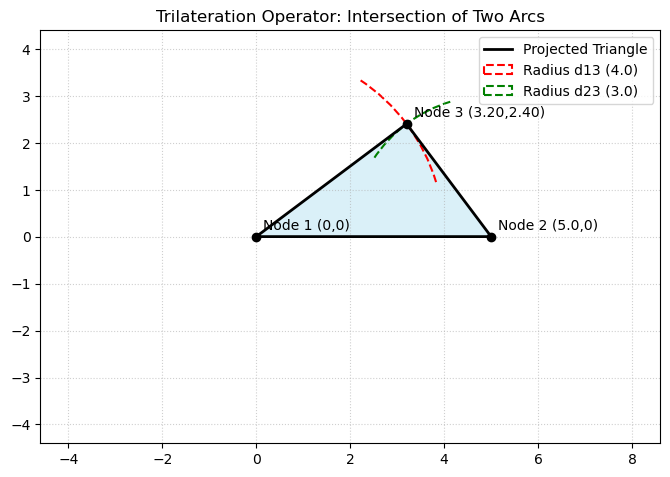

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def plot_trilateration_demo(d12, d13, d23):
    # 1. Calculate Coordinates
    p1 = np.array([0, 0])
    p2 = np.array([d12, 0])
    
    x3 = (d12**2 + d13**2 - d23**2) / (2 * d12)
    y3 = np.sqrt(max(0, d13**2 - x3**2))
    p3 = np.array([x3, y3])
    
    # 2. Setup Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Draw the triangle
    tri = np.array([p1, p2, p3, p1])
    ax.plot(tri[:, 0], tri[:, 1], 'k-', lw=2, label='Projected Triangle')
    ax.fill(tri[:, 0], tri[:, 1], color='skyblue', alpha=0.3)
    
    # 3. Add Arcs to show trilateration principle
    # Arc 1: Centered at Node 1 with radius d13
    angle1 = np.degrees(np.arctan2(y3, x3))
    arc1 = Arc(p1, width=2*d13, height=2*d13, theta1=angle1-20, theta2=angle1+20, 
               edgecolor='red', linestyle='--', lw=1.5, label=f'Radius d13 ({d13})')
    
    # Arc 2: Centered at Node 2 with radius d23
    angle2 = np.degrees(np.arctan2(y3, x3 - d12))
    # We adjust the angle because arctan2 is relative to the origin of the circle (Node 2)
    arc2 = Arc(p2, width=2*d23, height=2*d23, theta1=angle2-20, theta2=angle2+20, 
               edgecolor='green', linestyle='--', lw=1.5, label=f'Radius d23 ({d23})')
    
    ax.add_patch(arc1)
    ax.add_patch(arc2)
    
    # 4. Labeling
    nodes = np.array([p1, p2, p3])
    labels = ['Node 1 (0,0)', f'Node 2 ({d12},0)', f'Node 3 ({x3:.2f},{y3:.2f})']
    ax.scatter(nodes[:, 0], nodes[:, 1], color='black', zorder=5)
    
    for i, txt in enumerate(labels):
        ax.annotate(txt, (nodes[i, 0], nodes[i, 1]), xytext=(5, 5), textcoords='offset points')

    # Formatting
    ax.set_aspect('equal')
    ax.set_title("Trilateration Operator: Intersection of Two Arcs")
    ax.legend(loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# Execute with sample values
plot_trilateration_demo(d12=5.0, d13=4.0, d23=3.0)

#### 2. the edge operator

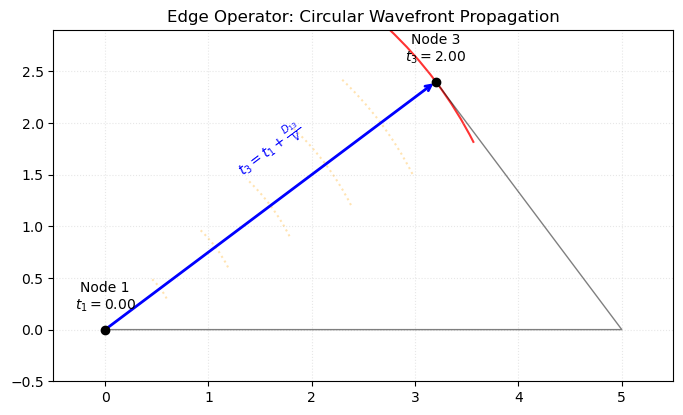

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

def plot_edge_wavefront(d12, d13, d23, t1, v1):
    # 1. Geometry Setup
    p1 = np.array([0, 0])
    p2 = np.array([d12, 0])
    x3 = (d12**2 + d13**2 - d23**2) / (2 * d12)
    y3 = np.sqrt(max(0, d13**2 - x3**2))
    p3 = np.array([x3, y3])
    
    # 2. Physics: Traveltime at Node 3
    t3 = t1 + (d13 / v1)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # 3. Draw Triangle
    tri = np.array([p1, p2, p3, p1])
    ax.plot(tri[:, 0], tri[:, 1], 'k-', lw=1, alpha=0.5)
    
    # 4. Plot Wavefront Arcs (Concentric around Node 1)
    # We plot arcs at regular intervals up to d13
    num_arcs = 6
    radii = np.linspace(d13/num_arcs, d13, num_arcs)
    angle_to_node3 = np.degrees(np.arctan2(y3, x3))
    
    for r in radii:
        # Drawing a small arc (20 degrees wide) centered on the edge 1-3
        color = 'orange' if r < d13 else 'red' # Highlight the final wavefront
        alpha = 0.3 if r < d13 else 0.8
        ls = ':' if r < d13 else '-'
        
        wavefront = Arc(p1, width=2*r, height=2*r, 
                        theta1=angle_to_node3-10, theta2=angle_to_node3+10, 
                        edgecolor=color, lw=1.5, alpha=alpha, linestyle=ls)
        ax.add_patch(wavefront)

    # 5. Draw the Edge path (Arrow)
    ax.annotate('', xy=p3, xytext=p1,
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))
    
    # 6. Labels and Annotations
    ax.scatter([p1[0], p3[0]], [p1[1], p3[1]], color='black', zorder=5)
    ax.text(p1[0], p1[1]+0.2, f"Node 1\n$t_1 = {t1:.2f}$", ha='center')
    ax.text(p3[0], p3[1]+0.2, f"Node 3\n$t_3 = {t3:.2f}$", ha='center')
    
    # Formula label
    ax.text(x3/2, y3/2 + 0.3, r"$t_3 = t_1 + \frac{D_{13}}{V}$", 
            color='blue', rotation=angle_to_node3, ha='center')

    # Formatting
    ax.set_aspect('equal')
    ax.set_title("Edge Operator: Circular Wavefront Propagation")
    ax.set_xlim(-0.5, d12 + 0.5)
    ax.set_ylim(-0.5, y3 + 0.5)
    ax.grid(True, linestyle=':', alpha=0.3)
    plt.show()

# Run the visualization
plot_edge_wavefront(d12=5.0, d13=4.0, d23=3.0, t1=0.0, v1=2.0)